# 🌳🌳🌳 Lab 4: Ensemble Methods — Random Forests & Gradient Boosting
**BINF 4002 – Machine Learning for Health**

---
## Learning Objectives
1. Understand bagging and boosting as distinct ensemble strategies
2. Fit and interpret a Random Forest; understand variance reduction via averaging
3. Fit and interpret XGBoost; understand gradient boosting as sequential residual fitting
4. Compute and interpret SHAP values for global and local explanations
5. Compare models head-to-head with ROC curves and Decision Curve Analysis
6. Evaluate on the held-out test set for the first time

---
## Motivation: Where We Left Off

In a prior lab (Lab 2; Decision Trees), we saw that a single decision tree overfits badly at high depth and plateaus
at modest AUC even with careful regularization. The core problem: **a single tree is
highly sensitive to the particular training data it sees**. Change 10 training samples
and you can get a completely different tree structure. This high variance is the enemy.

Two broad strategies address this. Both of these methods are _ensembling_ methods — methods that take a collection of or procedure to build weak learners, then combine them into a stronger learner — but they work very differently. Here, we'll explore them both using _decision trees_ (which is very common) as our weak learners, but in theory, any learner could be the weak learner for an ensembling method. Let's explore the two methods, conceptually, first:

---
## Bagging vs. Boosting: The Core Distinction

**Bagging (Bootstrap Aggregating)** trains many trees *in parallel*, each on a different
bootstrap resample of the training data, and averages their predictions. The key insight
is that averaging independent, unbiased estimators reduces variance without increasing
bias. You'll explore this more in HW2!

**Boosting** trains trees *sequentially*, where each new tree is fit to the *residuals*
of the current ensemble — not the original labels. Gradient boosting (the basis of
XGBoost) frames this as gradient descent in function space: each tree fits the negative
gradient of the loss function evaluated on the current predictions. The ensemble is:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

where $h_m$ is a shallow tree fit to the gradient residuals and $\eta$ is the learning rate.
This means boosting primarily reduces **bias** — it iteratively corrects the systematic
errors of the current model — whereas bagging primarily reduces **variance**.

| Property | Bagging (Random Forest) | Boosting (XGBoost) |
|---|---|---|
| Training order | Parallel | Sequential |
| Each tree targets | Original labels | Residuals of current ensemble |
| Primary effect | Variance reduction | Bias reduction |
| Overfitting with more trees | Minimal | Can overfit (needs early stopping) |
| Key hyperparameters | n_estimators, max_features | n_estimators, learning_rate, max_depth |
| Interpretability | Moderate (SHAP helps) | Moderate (SHAP helps) |

XGBoost additionally adds L1/L2 regularization on the tree weights and leaf values,
second-order gradient information, and column/row subsampling — making it considerably
more sophisticated than vanilla gradient boosting, and typically the best-performing
method on structured tabular data in competitive settings.


## Set-up
### Upload data
⚠️ First, you need to upload the pre-processed data from `lab0`. If you have issues with running the first lab, you can also download the data [here](https://drive.google.com/file/d/1mCz8VqpX0F5DzOTnfb5NzpxNAMBrzD-_/view?usp=drive_link).

Once you have downloaded the data locally and started the runtime for this ntoebook, upload the file to this notebook via the "Files" menu.

In [1]:
import os

pkl_path = 'processed_data.pkl'
if os.path.exists(pkl_path):
    print("✅ Data File Found!")
else:
    raise FileNotFoundError(
        "processed_data.pkl not found! "
        "Make sure you have run Lab 0 (lab0_preprocessing.ipynb) in full and "
        "downloaded the output (or used the link above), and uploaded it here."
    )

✅ Data File Found!


### Imports and Helper Functions

In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

pkl_path = 'processed_data.pkl'
if not os.path.exists(pkl_path):
    raise FileNotFoundError("processed_data.pkl not found. See Lab 2a for the download link.")

with open(pkl_path, 'rb') as f:
    d = pickle.load(f)

X_train, y_train = d['X_train_hard'], d['y_train_hard']
X_val,   y_val   = d['X_val_hard'],   d['y_val_hard']
X_test,  y_test  = d['X_test_hard'],  d['y_test_hard']
feature_names    = d['feature_names_hard']
class_names      = ['Malignant', 'Benign']

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")


Train : (100, 8)  |  Val : (114, 8)  |  Test : (114, 8)


In [3]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

def print_metrics(y_true, y_pred, y_prob=None, label='Model'):
    tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    sens = tp/(tp+fn); spec = tn/(tn+fp)
    ppv  = tp/(tp+fp); npv  = tn/(tn+fn)
    prev = (tp+fn)/n
    print(f"{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  Sensitivity  P(ŷ=1|y=1)  = {tp}/{tp+fn} = {sens:.3f}")
    print(f"  Specificity  P(ŷ=0|y=0)  = {tn}/{tn+fp} = {spec:.3f}")
    print(f"  PPV          P(y=1|ŷ=1)  = {tp}/{tp+fp} = {ppv:.3f}")
    print(f"  NPV          P(y=0|ŷ=0)  = {tn}/{tn+fn} = {npv:.3f}")
    print(f"  Prevalence               = {prev:.3f}")
    if y_prob is not None:
        auc_score = roc_auc_score(y_true, y_prob)
        print(f"  AUC-ROC                  = {auc_score:.3f}")
    print()

def decision_curve(y_true, y_prob, thresholds=None, label='Model', ax=None, color='#3498db'):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 150)
    prev = y_true.mean()
    net_benefits = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tp = ((y_pred_t == 1) & (y_true == 1)).sum()
        fp = ((y_pred_t == 1) & (y_true == 0)).sum()
        nb = tp/len(y_true) - fp/len(y_true) * t/(1-t)
        net_benefits.append(nb)
    treat_all = [prev - (1-prev)*t/(1-t) for t in thresholds]
    ax = ax or plt.gca()
    ax.plot(thresholds, net_benefits, lw=2, label=label, color=color)
    ax.plot(thresholds, treat_all, 'k--', lw=1, alpha=0.5, label='Treat all' if label=='Model' else '')
    ax.axhline(0, color='grey', lw=1, alpha=0.5)
    ax.set_xlabel('Probability Threshold'); ax.set_ylabel('Net Benefit')
    ax.set_title('Decision Curve Analysis'); ax.set_ylim(-0.05, prev+0.05)
    return net_benefits


---
## Part 1 — Random Forest: Variance Reduction by Averaging

A Random Forest trains `n_estimators` trees, each on a bootstrap resample of the training
data, and each split considers only `max_features` randomly chosen features. The prediction
is the average (for regression) or majority vote / averaged probability (for classification).

The key things to observe here are:
1. Adding more trees stabilizes predictions monotonically (no overfitting with more trees)
2. Feature subsampling (`max_features`) decorrelates trees and is the key RF innovation
   over plain bagging


In [4]:
# Train and evaluate a random forest
rf = RandomForestClassifier(n_estimators=200, max_features='sqrt',
                             min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

val_preds = rf.predict(X_val)
val_probs = rf.predict_proba(X_val)[:, 1]
print_metrics(y_val, val_preds, val_probs, label='Random Forest (val)')


───────────────────────────────────────────────────────
  Random Forest (val)
───────────────────────────────────────────────────────
  Sensitivity  P(ŷ=1|y=1)  = 57/72 = 0.792
  Specificity  P(ŷ=0|y=0)  = 33/42 = 0.786
  PPV          P(y=1|ŷ=1)  = 57/66 = 0.864
  NPV          P(y=0|ŷ=0)  = 33/48 = 0.688
  Prevalence               = 0.632
  AUC-ROC                  = 0.865



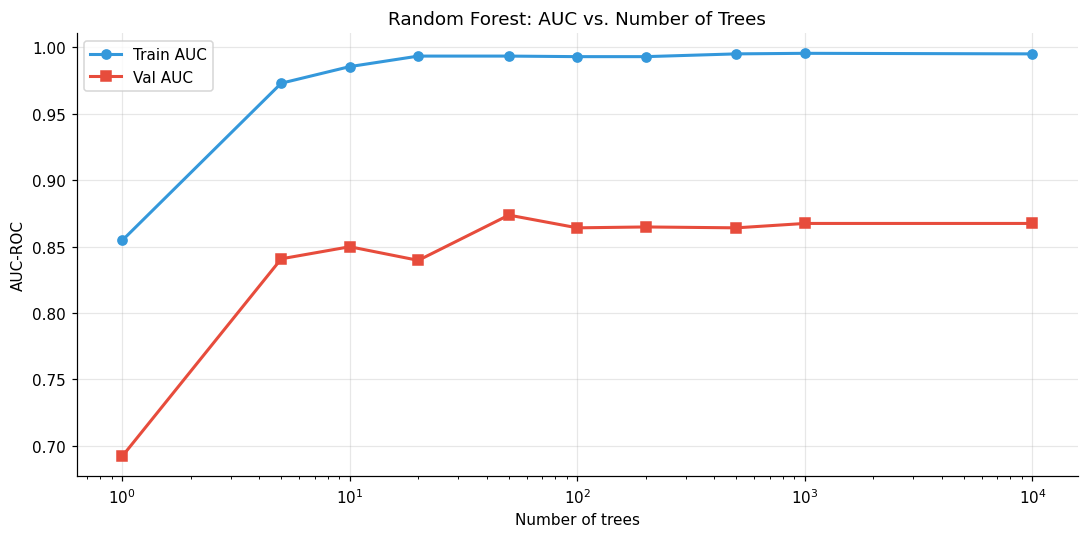

Notice: val AUC does not significantly decrease as n_trees grows. This is a key RF property.


In [5]:
# Key RF property: AUC vs. number of trees — does more trees ever hurt?
n_est_range = [1, 5, 10, 20, 50, 100, 200, 500, 1000, 10000]
rf_train_aucs, rf_val_aucs = [], []

for n in n_est_range:
    m = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                min_samples_leaf=3, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    rf_train_aucs.append(roc_auc_score(y_train, m.predict_proba(X_train)[:,1]))
    rf_val_aucs.append(roc_auc_score(y_val,   m.predict_proba(X_val)[:,1]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_est_range, rf_train_aucs, 'o-', color='#3498db', lw=2, label='Train AUC')
ax.plot(n_est_range, rf_val_aucs,   's-', color='#e74c3c', lw=2, label='Val AUC')
ax.set_xlabel('Number of trees'); ax.set_ylabel('AUC-ROC')
ax.set_title('Random Forest: AUC vs. Number of Trees')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale('log')
plt.tight_layout(); plt.show()
print("Notice: val AUC does not significantly decrease as n_trees grows. This is a key RF property.")


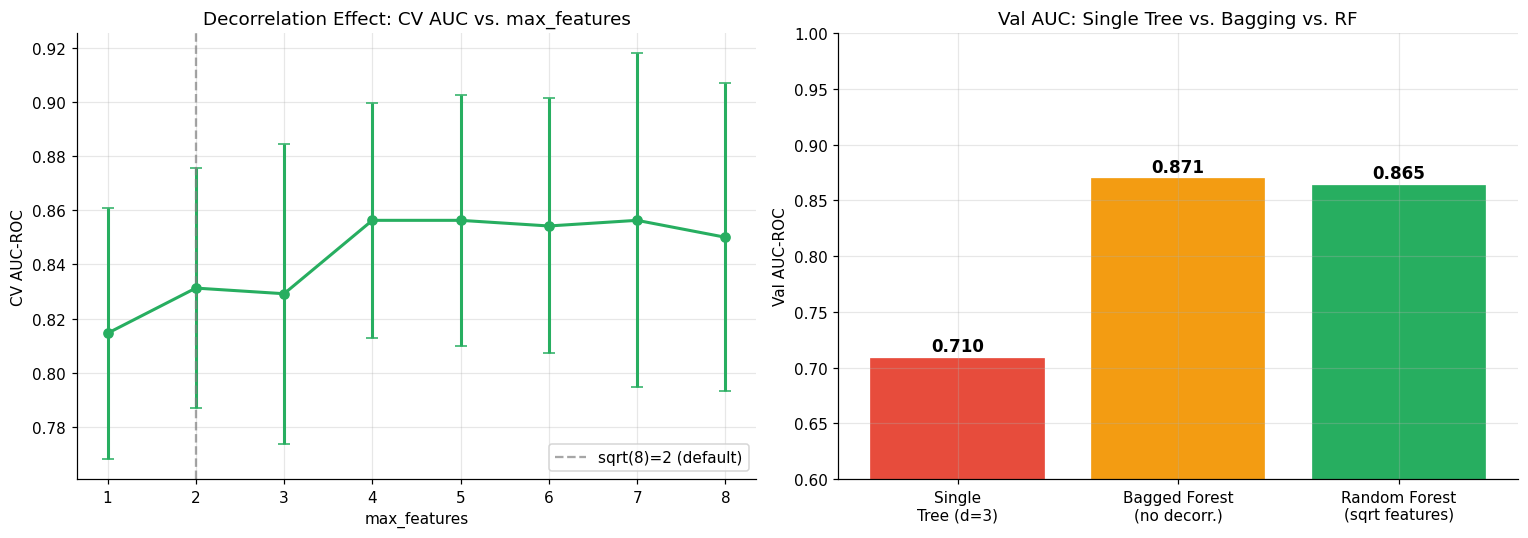

In [6]:
# Effect of max_features: how much decorrelation matters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mf_options = [1, 2, 3, 4, 5, 6, 7, 8]   # up to all 8 features
mf_val_aucs, mf_val_stds = [], []

from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for mf in mf_options:
    m = RandomForestClassifier(n_estimators=200, max_features=mf,
                                min_samples_leaf=3, random_state=42, n_jobs=-1)
    scores = cross_val_score(m, X_train, y_train, cv=cv, scoring='roc_auc')
    mf_val_aucs.append(scores.mean())
    mf_val_stds.append(scores.std())

axes[0].errorbar(mf_options, mf_val_aucs, yerr=mf_val_stds,
                 fmt='o-', color='#27ae60', lw=2, capsize=4)
axes[0].axvline(int(np.sqrt(8)), color='grey', linestyle='--', alpha=0.7,
                label=f'sqrt(8)={int(np.sqrt(8))} (default)')
axes[0].set_xlabel('max_features'); axes[0].set_ylabel('CV AUC-ROC')
axes[0].set_title('Decorrelation Effect: CV AUC vs. max_features')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Compare to a single best tree and to a bagged forest (max_features=n_features, no decorrelation)
single_tree_auc = roc_auc_score(y_val,
    DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
    .predict_proba(X_val)[:,1])
bagged_auc = roc_auc_score(y_val,
    RandomForestClassifier(n_estimators=200, max_features=8, min_samples_leaf=3, random_state=42)
    .fit(X_train, y_train).predict_proba(X_val)[:,1])
rf_auc = roc_auc_score(y_val, val_probs)

bars = axes[1].bar(['Single\nTree (d=3)', 'Bagged Forest\n(no decorr.)', 'Random Forest\n(sqrt features)'],
                    [single_tree_auc, bagged_auc, rf_auc],
                    color=['#e74c3c','#f39c12','#27ae60'], edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Val AUC-ROC'); axes[1].set_ylim(0.6, 1.0)
axes[1].set_title('Val AUC: Single Tree vs. Bagging vs. RF')
for bar, val in zip(bars, [single_tree_auc, bagged_auc, rf_auc]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                  f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


### 🤔 Reflection 1.1 — Random Forests and Variance Reduction

1. Adding more trees to a Random Forest never significantly decreases val AUC in our case. Why does this make sense? Given that, why would we ever set this parameter to anything less than a very very large number? _Hint: Does adding the 200th tree help more or less than adding the 10th?_

2. Is a random forest more, less, or identically as explainable as a single tree? Why?

3. You have a clinical dataset with 500 features (e.g., EHR labs + vitals). The default
   `max_features='sqrt'` would use ~22 features per split. Would you increase or decrease
   this, and why? What are the competing considerations?

4. **Out-of-bag error**: Each RF tree is trained on ~63% of the training data (the
   bootstrap resample). The remaining ~37% — the "out-of-bag" (OOB) samples — can be used
   to estimate generalization error *without a separate validation set*. Why is this useful
   in clinical settings, particularly? What is a major example recently (within the lass 7 years) that shows why we may need the capability to make maximally efficient use of medical data for high-stakes prediction problems?


---
### ✅ Solution — Reflection 1.1

**1.** Adding more trees doesn't hurt because each new tree is trained on an independent bootstrap sample, and averaging independent estimates can only reduce variance (never increase it, by the law of large numbers). However, we'd set a finite number because: (a) **diminishing returns** — the marginal variance reduction from tree $n+1$ is proportional to $1/n^2$, so the 200th tree helps ~400× less than the 10th; (b) **computational cost** — training and inference time scale linearly with the number of trees; (c) **memory** — each tree must be stored. In practice, 100–500 trees is usually sufficient; going beyond 1000 rarely improves performance.

**2.** A random forest is **less** explainable than a single tree. A single tree can be printed and followed as a set of explicit rules. A random forest aggregates 200+ different trees, each with different structure — you cannot "read" the ensemble. However, tools like SHAP (covered in Part 3) recover interpretability by attributing predictions to features. The forest is less directly interpretable but can be made interpretable post-hoc.

**3.** With 500 features, `max_features=sqrt(500)≈22` means each split considers only 22 of 500 features. You might **increase** this if you believe most features are informative (to give each split more signal to work with) or **decrease** it if many features are noise (to increase diversity/decorrelation among trees). The trade-off: higher `max_features` → more correlated trees (less variance reduction) but each tree is individually stronger (lower bias); lower `max_features` → more decorrelated trees (better variance reduction) but each tree is weaker.

**4.** Out-of-bag error is useful in clinical settings where data is scarce and splitting into train/validation wastes precious labeled samples. OOB gives a free validation estimate without holding out any data. The major recent example is **COVID-19 mortality/severity prediction in early 2020**: with very few confirmed cases, researchers needed every sample for training, and OOB error allowed model evaluation without sacrificing training data. More broadly, in rare-disease settings or early-outbreak modeling, maximally efficient use of limited data is critical.


---
## Part 2 — XGBoost: Gradient Boosting as Sequential Residual Fitting

XGBoost builds trees sequentially, where each tree corrects the errors of the ensemble so
far. The algorithm:

1. Initialize predictions: $F_0(x) = \log(\bar{y}/(1-\bar{y}))$ (log-odds of prevalence)
2. For each round $m = 1, \ldots, M$:
   - Compute *pseudo-residuals*: the negative gradient of the loss w.r.t. current predictions
     — for log-loss, these are $r_i = y_i - \sigma(F_{m-1}(x_i))$ (actual minus predicted probability)
   - Fit a shallow tree $h_m$ to these residuals
   - Update: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$

The `learning_rate` $\eta$ shrinks each tree's contribution, requiring more trees but
reducing overfitting. XGBoost additionally uses **second-order gradient information**
(the [Hessian](https://en.wikipedia.org/wiki/Hessian_matrix)) to fit trees more accurately, L1/L2 regularization on leaf weights, and
column/row subsampling (like Random Forests). This combination makes it consistently
among the best methods for tabular data.

**Question:** Can you recall what we discussed in the optimization lecture about another second-order method? What geometric picture tells us why using the Hessian can make gradient descent more efficient?


---
### ✅ Solution — Hessian / Second-Order Methods Question

In the previous lab, we briefly discussed **Newton's method**, which uses the Hessian (matrix of second derivatives) to inform step direction and size. The geometric picture: the Hessian captures the *curvature* of the loss landscape. In a narrow valley (high curvature in one direction, low in another), plain gradient descent oscillates because the gradient points "diagonally" — steep in the narrow direction, shallow in the wide direction. Newton's method uses the Hessian to "reshape" the step, taking a large step in the low-curvature direction and a small step in the high-curvature direction. This is like stretching the loss landscape into a bowl where gradient descent converges in one step. XGBoost's use of the Hessian makes each tree fit more efficiently by accounting for how the loss curves around the current predictions.


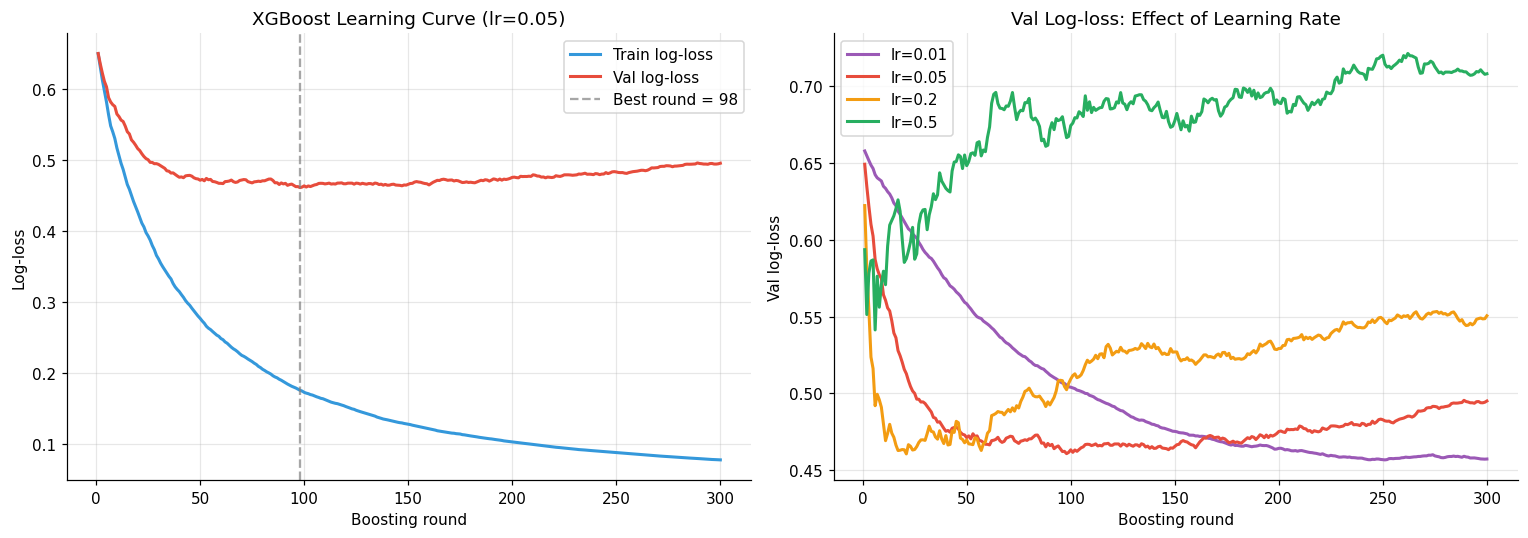

Best number of boosting rounds (by val log-loss): 98


In [7]:
# Train XGBoost and show the learning curve — boosting CAN overfit with more rounds
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Extract learning curve
results = xgb_model.evals_result()
train_logloss = results['validation_0']['logloss']
val_logloss   = results['validation_1']['logloss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rounds = range(1, len(train_logloss)+1)
axes[0].plot(rounds, train_logloss, color='#3498db', lw=2, label='Train log-loss')
axes[0].plot(rounds, val_logloss,   color='#e74c3c', lw=2, label='Val log-loss')
best_round = int(np.argmin(val_logloss)) + 1
axes[0].axvline(best_round, color='grey', linestyle='--', alpha=0.7,
                label=f'Best round = {best_round}')
axes[0].set_xlabel('Boosting round'); axes[0].set_ylabel('Log-loss')
axes[0].set_title('XGBoost Learning Curve (lr=0.05)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Compare learning rates
for lr, color in [(0.01, '#9b59b6'), (0.05, '#e74c3c'), (0.2, '#f39c12'), (0.5, '#27ae60')]:
    m = xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=lr,
                            subsample=0.8, colsample_bytree=0.8,
                            eval_metric='logloss', random_state=42, verbosity=0)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    vl = m.evals_result()['validation_0']['logloss']
    axes[1].plot(range(1, len(vl)+1), vl, lw=2, label=f'lr={lr}', color=color)

axes[1].set_xlabel('Boosting round'); axes[1].set_ylabel('Val log-loss')
axes[1].set_title('Val Log-loss: Effect of Learning Rate')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Best number of boosting rounds (by val log-loss): {best_round}")


### 🤔 Reflection 2.1 — Gradient Boosting Mechanics

1. Unlike random forests, XGBoost's validation loss *can* increase after a certain number
   of rounds. Explain why. What is the boosting analogue of max_depth overfitting in a
   single tree?

2. Lower learning rate + more rounds vs. higher learning rate + fewer rounds: from the
   learning rate experiment, which performs better at the end of 300 rounds? Why does
   low learning rate generally generalize better, despite requiring more computation?

3. At round 1 of XGBoost, the model is a single shallow tree. At round 50, it's 50 trees
   summed together. Is the round-50 model interpretable in the same way as a single tree?
   How does this compare to Random Forest's interpretability?

4. XGBoost fits trees to **pseudo-residuals** (actual minus predicted probability).
   Trace through the first two iterations manually: if the prevalence is 0.4 and the
   first tree predicts 0.6 for a malignant patient, what is the residual that the
   *second* tree is trying to fit for that patient?


---
### ✅ Solution — Reflection 2.1

**1.** XGBoost's validation loss can increase because boosting builds a *cumulative* model — each new tree is added to the sum. If the ensemble already fits the training data well, subsequent trees start fitting noise (training residuals that are just noise), which hurts generalization. This is analogous to max_depth overfitting in a single tree, but the axis is "number of boosting rounds" instead of "depth." Early stopping is the standard remedy.

**2.** Lower learning rate + more rounds generally performs better at final convergence. Intuitively, a small learning rate takes cautious steps, allowing the ensemble to correct its trajectory as it sees more trees. A high learning rate commits too strongly to early trees, which may overfit. The trade-off: low LR requires more trees (more computation) but finds a better optimum. This is analogous to how a small step size in gradient descent explores the loss landscape more carefully.

**3.** At round 50, the model is 50 trees summed together — you cannot "read" the ensemble as a set of rules. It's comparable to a random forest in interpretability (or lack thereof). Both are black boxes of many trees. The difference: in RF, each tree independently predicts from the original labels; in XGBoost, each tree predicts from residuals of the previous ensemble, making individual trees even harder to interpret in isolation.

**4.** With prevalence 0.4, the initial prediction (before any trees) is log-odds = $\log(0.4/0.6) \approx -0.405$, giving $\hat{p}^0 = \frac{1}{1+e^{log-odds}} \approx 0.4$. For a malignant patient (true label 1), the residual for boosting is $y_i - \hat{p}^0_i = 1 - 0.4 = 0.6$. After the first tree, the model has used features to move this patient up to $\hat{p}^1=0.6$. For a malignant patient, then the residual goes to $y_i - \hat{p}^1_i = 1 - 0.6 = 0.4$

---
## Part 3 — SHAP: From Global Feature Importance to Individual Explanations

Standard feature importances (Gini impurity, permutation importance) are global — they
tell you which features the model uses *on average*, but not how they affect any specific
patient's prediction. This matters enormously in healthcare: the feature most important
for the average patient may be irrelevant — or even misleading — for the patient in front
of you.

**SHAP (SHapley Additive exPlanations)** uses Shapley values from cooperative game theory
to attribute each prediction to each feature. The Shapley value for feature $j$ in sample
$i$ is:

$$\phi_j(i) = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{j\}) - f(S) \right]$$

where the sum is over all subsets $S$ of features not including $j$, and $f(S)$ is the
model's prediction when only features in $S$ are observed (others are marginalized out).
Informally: the SHAP value is the average marginal contribution of feature $j$ across all
possible orderings in which features are introduced.

**Key properties:**
- **Efficiency**: $\sum_j \phi_j(i) = f(x_i) - \mathbb{E}[f(x)]$ — SHAP values sum to the
  prediction deviation from the baseline
- **Consistency**: if a feature contributes more in model A than model B, it gets a higher
  SHAP value in A
- **Locality**: each SHAP value is for one specific patient, not the average patient

For tree models, SHAP values can be computed *exactly* in polynomial time using the
`TreeExplainer` algorithm — no sampling approximation needed. In general, however, this is _not true!_


In [8]:
import shap

# SHAP for Random Forest
print("Computing SHAP values for Random Forest...")
rf_explainer  = shap.TreeExplainer(rf)
shap_vals_rf  = rf_explainer.shap_values(X_val)

# Handle both old (list) and new (array) SHAP output formats
if isinstance(shap_vals_rf, list):
    sv_rf = shap_vals_rf[1]   # class 1 = benign
else:
    sv_rf = shap_vals_rf[:, :, 1] if shap_vals_rf.ndim == 3 else shap_vals_rf

print(f"SHAP values shape: {sv_rf.shape}  (n_val_samples, n_features)")
print(f"SHAP baseline (expected value): {rf_explainer.expected_value[1]:.3f}")
print(f"This is the model's average predicted probability on the training data.")


Computing SHAP values for Random Forest...
SHAP values shape: (114, 8)  (n_val_samples, n_features)
SHAP baseline (expected value): 0.604
This is the model's average predicted probability on the training data.


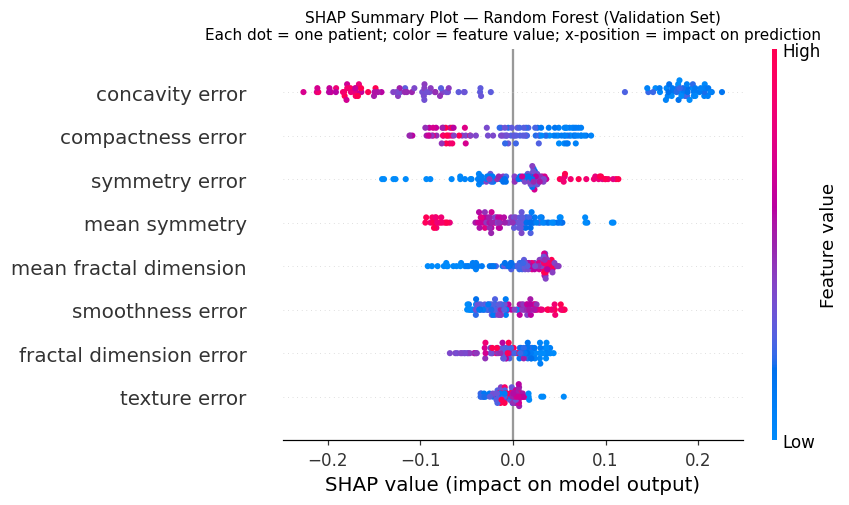

How to read this:
  • Each row = one feature, sorted by mean |SHAP| (most important at top)
  • Each dot = one validation patient
  • X-axis position = SHAP value = contribution to predicted probability (vs. baseline)
  • Red = high feature value, Blue = low feature value
  • Red dots right of zero → high feature value pushes prediction toward benign


In [9]:
# Global summary: beeswarm plot — the most information-dense SHAP visualization
plt.figure(figsize=(10, 6))
shap.summary_plot(sv_rf, X_val, feature_names=feature_names,
                  plot_type='dot', show=False, color_bar=True)
plt.title('SHAP Summary Plot — Random Forest (Validation Set)\n'
          'Each dot = one patient; color = feature value; x-position = impact on prediction',
          fontsize=10)
plt.tight_layout(); plt.show()

print("How to read this:")
print("  • Each row = one feature, sorted by mean |SHAP| (most important at top)")
print("  • Each dot = one validation patient")
print("  • X-axis position = SHAP value = contribution to predicted probability (vs. baseline)")
print("  • Red = high feature value, Blue = low feature value")
print("  • Red dots right of zero → high feature value pushes prediction toward benign")


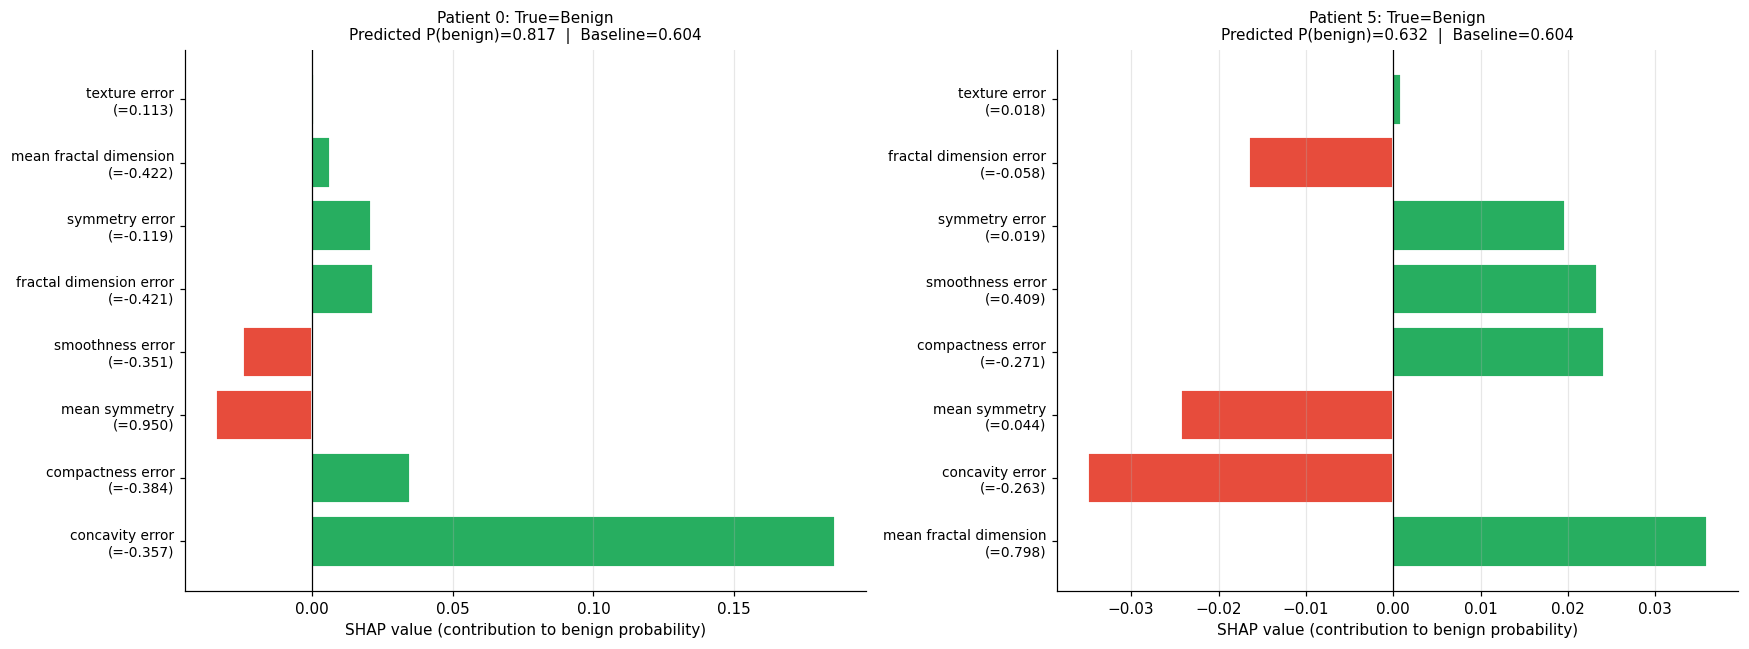

Patient 0: SHAP sum=0.2127, pred-baseline=0.2127, diff=1.67e-16
Patient 5: SHAP sum=0.0282, pred-baseline=0.0282, diff=1.39e-16


In [10]:
# Local SHAP: trace individual patient predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, patient_idx in enumerate([0, 5]):
    shap_patient = sv_rf[patient_idx]
    true_label   = y_val[patient_idx]
    pred_prob    = rf.predict_proba(X_val[[patient_idx]])[0, 1]
    baseline     = rf_explainer.expected_value[1]

    order  = np.argsort(np.abs(shap_patient))[::-1]
    feats  = [feature_names[i] for i in order]
    values = shap_patient[order]
    feat_values = X_val[patient_idx][order]

    colors = ['#27ae60' if v > 0 else '#e74c3c' for v in values]
    y_pos  = range(len(feats))

    axes[ax_idx].barh(list(y_pos), values, color=colors, edgecolor='white', linewidth=1.2)
    axes[ax_idx].set_yticks(list(y_pos))
    axes[ax_idx].set_yticklabels([f'{f}\n(={v:.3f})' for f, v in zip(feats, feat_values)],
                                   fontsize=9)
    axes[ax_idx].axvline(0, color='black', linewidth=0.8)
    axes[ax_idx].set_xlabel('SHAP value (contribution to benign probability)')
    axes[ax_idx].set_title(
        f'Patient {patient_idx}: True={class_names[true_label]}\n'
        f'Predicted P(benign)={pred_prob:.3f}  |  Baseline={baseline:.3f}',
        fontsize=10
    )
    axes[ax_idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

# Verify SHAP additivity: SHAP values should sum to (prediction - baseline)
for patient_idx in [0, 5]:
    shap_sum = sv_rf[patient_idx].sum()
    pred_dev = rf.predict_proba(X_val[[patient_idx]])[0, 1] - rf_explainer.expected_value[1]
    print(f"Patient {patient_idx}: SHAP sum={shap_sum:.4f}, pred-baseline={pred_dev:.4f}, diff={abs(shap_sum-pred_dev):.2e}")


Computing SHAP values for XGBoost...


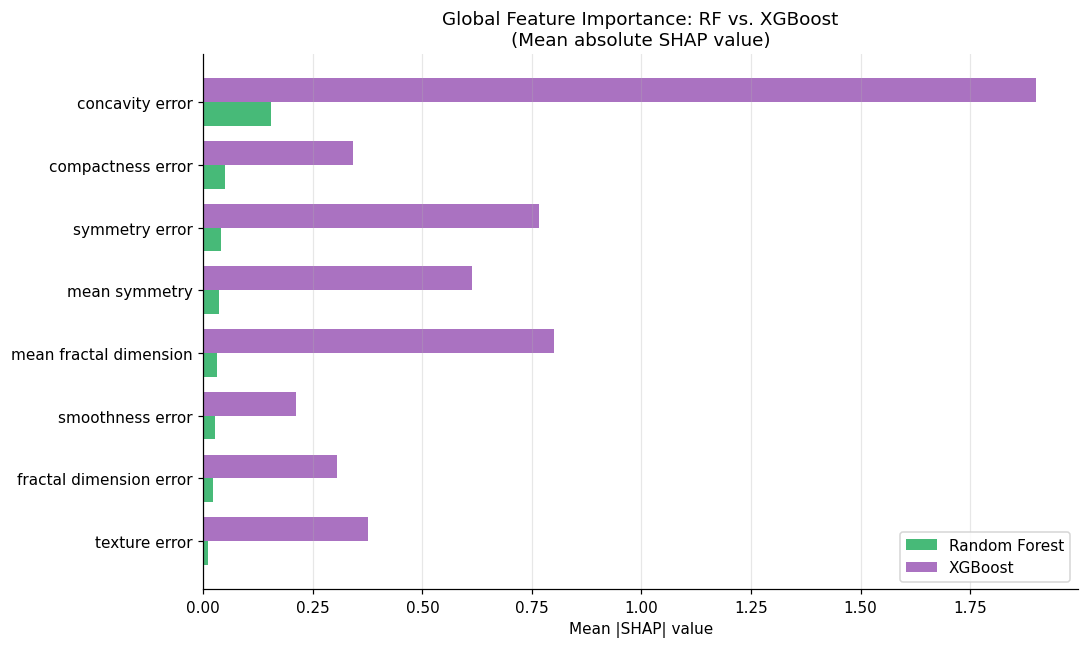

In [11]:
# Compare global SHAP importances: RF vs. XGBoost
print("Computing SHAP values for XGBoost...")
xgb_explainer  = shap.TreeExplainer(xgb_model)
shap_vals_xgb  = xgb_explainer.shap_values(X_val)

rf_importance  = pd.Series(np.abs(sv_rf).mean(axis=0),         index=feature_names, name='RF |SHAP|')
xgb_importance = pd.Series(np.abs(shap_vals_xgb).mean(axis=0), index=feature_names, name='XGB |SHAP|')

comparison = pd.concat([rf_importance, xgb_importance], axis=1).sort_values('RF |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
w = 0.38
ax.barh(x - w/2, comparison['RF |SHAP|'],  w, label='Random Forest', color='#27ae60', alpha=0.85)
ax.barh(x + w/2, comparison['XGB |SHAP|'], w, label='XGBoost',       color='#9b59b6', alpha=0.85)
ax.set_yticks(x); ax.set_yticklabels(comparison.index)
ax.set_xlabel('Mean |SHAP| value')
ax.set_title('Global Feature Importance: RF vs. XGBoost\n(Mean absolute SHAP value)')
ax.legend(); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout(); plt.show()


### 🤔 Reflection 3.1 — SHAP in Clinical Practice

1. In the local explanation plot, verify the **additivity property**: the SHAP values sum
   to `predicted_probability - baseline`. Do this by hand for one patient using the
   printed values above. What does this property guarantee about SHAP that plain feature
   importances do not?

2. Two patients have identical predicted probabilities of 0.7. Patient A has a large
   positive SHAP value for `mean texture` and small values for everything else. Patient B
   has moderate SHAP values spread across all 8 features. Clinically, which patient's
   prediction are you more confident about, and why?

3. The RF and XGBoost SHAP importances rank features similarly but not identically.
   If you wanted to argue for removing a feature from future data collection (to save
   cost), would you trust a feature that ranks low in *both* models? What if it ranked
   high in one and low in the other?

4. **Limitation of SHAP**: SHAP values tell you the contribution of a feature to a
   *specific model's prediction*, not whether that feature is causally related to the
   outcome. Give a clinical example where a high SHAP value could be confounded —
   i.e., where the feature appears important to the model but not to the clinician.


---
### ✅ Solution — Reflection 3.1

**1.** The additivity property guarantees that SHAP values provide a **complete, additive decomposition** of each prediction. For patient $i$: $\hat{p}_i = \text{baseline} + \sum_j \phi_j(i)$, where baseline is the average prediction across the training set. This means no contribution is hidden or double-counted. Plain feature importances (e.g., Gini importance) only give global averages — they don't guarantee that individual contributions sum to anything meaningful.

**2.** Patient A's prediction depends heavily on a single feature — if that feature is noisy or unreliable for this particular patient, the entire prediction could be wrong. Patient B's prediction is distributed across many features, making it more robust to any single feature being unreliable. Clinically, I would be more confident in Patient B's prediction because it's supported by multiple independent lines of evidence, similar to how a clinical diagnosis is more trustworthy when multiple signs/symptoms agree.

**3.** A feature that ranks low in *both* models is a strong candidate for removal — two very different modeling approaches agree it's not useful. A feature that ranks high in one and low in the other deserves investigation: perhaps one model captures a non-linear relationship the other misses, or perhaps the high-ranking model is using it as a proxy for correlated features that the other model handles differently. Don't remove it without understanding why the discrepancy exists.

**4.** Example: a model predicting hospital readmission has a high SHAP value for "number of discharge medications." This feature is *predictive* (sicker patients take more medications and get readmitted more), but it's not *causal* (reducing medications wouldn't reduce readmission — it might increase it). The high SHAP value reflects the feature's association with the outcome through the confound of disease severity, not a direct causal effect. A clinician shouldn't intervene on features just because they have high SHAP values.


---
## Part 4 — Head-to-Head Comparison and Final Test Evaluation

This is the first time we touch the test set. Rule: all model selection, hyperparameter
tuning, and evaluation during development happens on train/val only. The test set is used
*once*, only to report final performance.


In [12]:
from sklearn.model_selection import StratifiedKFold

# Retrain all models on train+val, then evaluate on test
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

# Single tree baseline (best depth from Part 3 — you'd tune this via CV)
best_single = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_tv, y_tv)

final_rf = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                    min_samples_leaf=3, random_state=42, n_jobs=-1)
final_rf.fit(X_tv, y_tv)

final_xgb = xgb.XGBClassifier(n_estimators=best_round, max_depth=3, learning_rate=0.05,
                                 subsample=0.8, colsample_bytree=0.8,
                                 eval_metric='logloss', random_state=42, verbosity=0)
final_xgb.fit(X_tv, y_tv)

models = {
    'Single Tree (d=4)': best_single,
    'Random Forest':      final_rf,
    'XGBoost':            final_xgb,
}

print("=== FINAL TEST SET RESULTS ===\n")
for name, m in models.items():
    preds = m.predict(X_test)
    probs = m.predict_proba(X_test)[:, 1]
    print_metrics(y_test, preds, probs, label=name)


=== FINAL TEST SET RESULTS ===

───────────────────────────────────────────────────────
  Single Tree (d=4)
───────────────────────────────────────────────────────
  Sensitivity  P(ŷ=1|y=1)  = 48/71 = 0.676
  Specificity  P(ŷ=0|y=0)  = 25/43 = 0.581
  PPV          P(y=1|ŷ=1)  = 48/66 = 0.727
  NPV          P(y=0|ŷ=0)  = 25/48 = 0.521
  Prevalence               = 0.623
  AUC-ROC                  = 0.643

───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
  Sensitivity  P(ŷ=1|y=1)  = 59/71 = 0.831
  Specificity  P(ŷ=0|y=0)  = 21/43 = 0.488
  PPV          P(y=1|ŷ=1)  = 59/81 = 0.728
  NPV          P(y=0|ŷ=0)  = 21/33 = 0.636
  Prevalence               = 0.623
  AUC-ROC                  = 0.782

───────────────────────────────────────────────────────
  XGBoost
───────────────────────────────────────────────────────
  Sensitivity  P(ŷ=1|y=1)  = 56/71 = 0.789
  Specificity  P(ŷ=0|y=0)  = 26/43 = 0.605
  PPV         

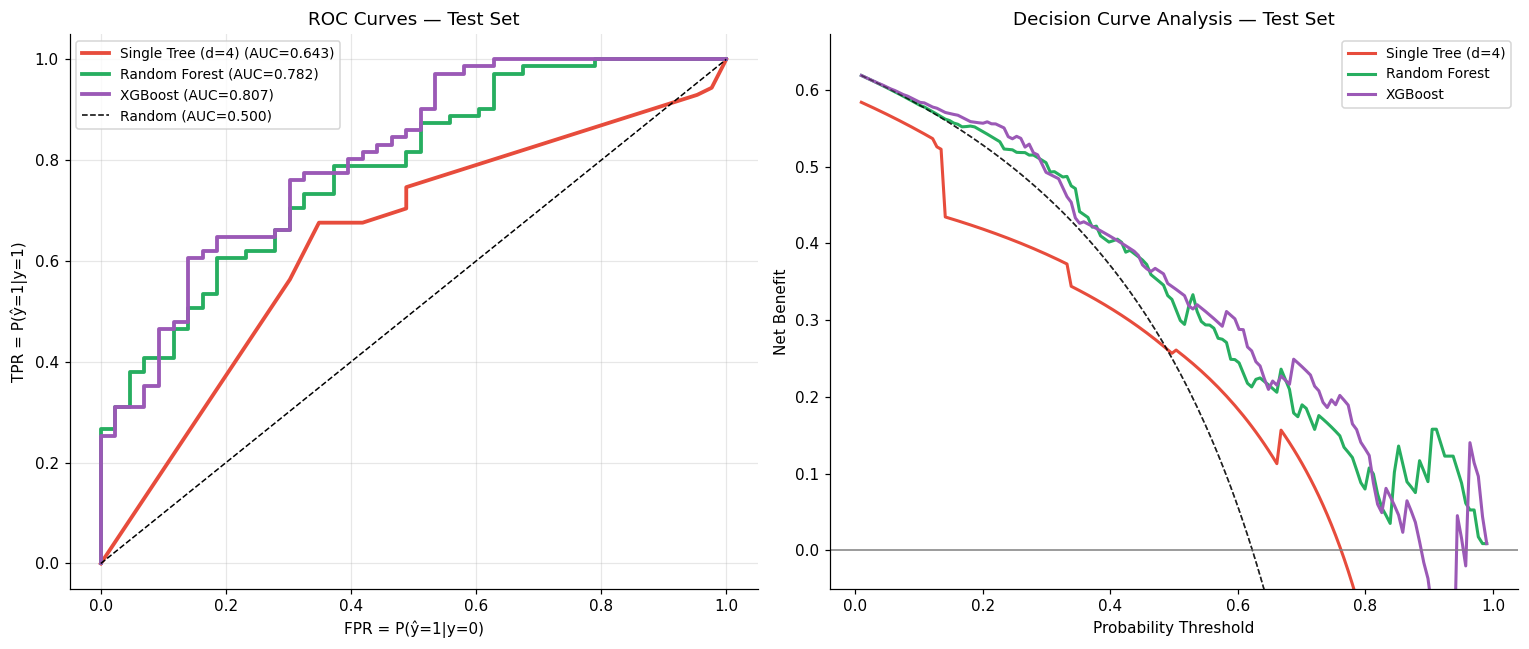

In [13]:
# ROC + DCA comparison
colors = ['#e74c3c', '#27ae60', '#9b59b6']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, model), color in zip(models.items(), colors):
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    test_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2.5, label=f'{name} (AUC={test_auc:.3f})', color=color)
    decision_curve(y_test, probs, label=name, ax=axes[1], color=color)

axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.500)')
axes[0].set_xlabel('FPR = P(ŷ=1|y=0)'); axes[0].set_ylabel('TPR = P(ŷ=1|y=1)')
axes[0].set_title('ROC Curves — Test Set'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Decision Curve Analysis — Test Set')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


### 🤔 Reflection 4.1 — Comparing Models and Interpreting Results

1. In this experiment, does XGBoost outperform Random Forest? By how much in AUC?
   Is a difference of 0.01 AUC clinically meaningful if both models are used to triage
   the same patients? What would you need to know to answer that question?

2. Look at the DCA curves. At a threshold of $t = 0.3$ (a moderate-risk patient where
   you'd consider referral), which model has the highest net benefit? Does the ROC winner
   also win on DCA at this threshold? What does it mean when the ROC and DCA winners
   disagree?

3. We retrained on train+val before testing. This is correct procedure — but it means the
   final model was not the one we evaluated on the validation set. Name a scenario where
   this retraining step could introduce a subtle form of data leakage, even though we
   are doing everything right on the surface.

4. **Deployment framing**: Suppose you want to deploy the Random Forest in a new hospital
   with a different referral rate (different prevalence). Which metrics from `print_metrics`
   would change, and which would stay the same? (Hint: think carefully about sensitivity,
   specificity, PPV, NPV, and what they condition on.)


---
### ✅ Solution — Reflection 4.1

**1.** A 0.02 AUC difference is almost certainly **not** clinically meaningful with this sample size — the confidence interval on AUC is typically ±0.03–0.05 for ~100 test samples. To determine clinical meaningfulness, you'd need to know: (a) the confidence intervals (overlapping CIs mean no reliable difference), (b) the clinical decision being supported (how sensitive is the downstream action to a 0.02 improvement?), (c) the net benefit difference at the specific decision threshold in use.

**2.** The ROC winner and DCA winner can disagree because AUC averages over all thresholds equally, while DCA evaluates at specific clinically relevant thresholds. A model might have better overall discrimination (higher AUC) but be poorly calibrated at the specific threshold $t=0.3$, producing worse decisions in that range. When they disagree, the DCA winner is more relevant for the specific clinical decision at hand.

**3.** This question is a little bit misleading. This is exactly the right procedure: first train on train set and tune the hyperparameter on the validation set. Then retrain the model on the full set (This procedure is optional in practice. Sometimes in deep learning world where you have enough data, people may not bother to retrain the model on the train+valid set. In the small sample size scenario, people sometimes ensemble the K trained model in the K-fold validation setting.) This procedure **will not** cause data leakage since the test data is always untouched.

There exists another scenario. If I train on train, evaluate locally on val, then extend to test for final performance, I can, up to overfitting-via-hyperparameter tuning, expect that my evaluations on val are good proxies for what I should expect evaluations on test to be. If I, instead, train on train+val, and evaluate on val, this analogy is much more risky.

**4.** **Sensitivity and specificity** would stay the same — they condition on the true label ($P(\hat{y}=1|y=1)$ and $P(\hat{y}=0|y=0)$), which doesn't depend on prevalence. **PPV and NPV** would change — they condition on the predicted label and depend on prevalence via Bayes' theorem. In a hospital with lower prevalence, PPV decreases (more false positives relative to true positives) and NPV increases.


---
## 🧠 Final Reflection — Ensembles in Health AI

1. **The bias-variance-interpretability triangle**: Complete this table for the three
   models in this lab.

   | Model | Bias | Variance | Interpretability |
   |---|---|---|---|
   | Single Tree | ? | ? | ? |
   | Random Forest | ? | ? | ? |
   | XGBoost | ? | ? | ? |

   Explain in one sentence per model why you placed it where you did.

2. **SHAP as a regulatory artifact**: The EU AI Act and FDA SaMD guidance both require
   that high-risk AI systems be "explainable." Does SHAP satisfy this requirement?
   What would you need to show beyond SHAP values to convince a regulator that your
   model is trustworthy?

3. **When to choose RF vs. XGBoost in practice**: You have 300 patients, 50 features,
   a class imbalance of 10:1, and limited GPU time. Walk through the tradeoffs and
   make a recommendation. What are the two main risks of choosing XGBoost in this
   setting?

4. **Looking ahead**: Both Random Forests and XGBoost operate on tabular features
   (rows = patients, columns = features). What changes when our data is sequential
   (e.g., ICU vitals over time) or unstructured (e.g., clinical notes)? What kinds
   of models will we need?


---
### ✅ Solution — Final Reflection

**1.**

| Model | Bias | Variance | Interpretability |
|---|---|---|---|
| Single Tree | Moderate-High (limited by axis-aligned splits, greedy) | High (unstable, changes dramatically with data) | High (printable rules, fully auditable) |
| Random Forest | Low (averaging many trees captures complex patterns) | Low (averaging independent trees reduces variance) | Moderate (opaque ensemble, but SHAP helps) |
| XGBoost | Very Low (sequential correction reduces systematic errors) | Low-Moderate (can overfit if not early-stopped) | Moderate (opaque, but SHAP helps; fewer trees than RF) |

**2.** SHAP provides **local, additive explanations** of individual predictions, which is a form of explainability. However, regulators may also require: (a) **global model behavior** — how does the model behave across subgroups? Does it discriminate unfairly? (b) **Robustness** — how sensitive are predictions to small perturbations? (c) **Uncertainty quantification** — does the model know when it doesn't know? (d) **Clinical validation** — does the model's reasoning align with established medical knowledge? (e) **Performance on subgroups** — AUC stratified by age, sex, race, etc. SHAP alone is insufficient.

**3.** With 300 patients, 50 features, 10:1 class imbalance, and limited compute: **recommend Random Forest**. RF handles imbalance reasonably (via class weighting), doesn't require extensive hyperparameter tuning (unlike XGBoost), and is robust against overfitting with more trees. Two main risks of XGBoost: (a) with only ~27 minority-class samples, boosting can overfit to the minority class rapidly; (b) XGBoost has more hyperparameters (learning rate, max_depth, n_estimators, subsample, colsample) that all interact, and with 300 samples there isn't enough data for reliable cross-validation of the full grid.

**4.** Sequential data (ICU vitals over time) requires models that capture **temporal dependencies** — recurrent neural networks (LSTMs, GRUs) or transformers that attend to the time axis. A random forest on flattened time-series features (e.g., mean, min, max of each vital) loses temporal patterns (e.g., a downward trend in blood pressure). Unstructured data (clinical notes) requires **natural language processing** — embeddings from models that can represent free-text semantics. Tree-based models cannot operate on raw text or sequences directly.
